# 🛡️ Deepfake Detection — Upgraded Pipeline
### EfficientNetV2B2 + ResNet101V2 Ensemble | AUC-ROC | Grad-CAM | Risk Scoring

---
## CELL 1 — Setup & Verification

In [1]:
# ==============================================================================
# CELL 1: SETUP AND VERIFICATION
# ==============================================================================

# Step 1.1: Import Libraries
import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from google.colab import drive
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.applications import EfficientNetV2B2, ResNet101V2
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Step 1.2: Force Remount Google Drive
print("Attempting to force remount Google Drive...")
drive.mount('/content/drive', force_remount=True)
print("✅ Drive remounted successfully.")

# Step 1.3: Define File Paths
BASE_PATH     = '/content/drive/MyDrive/Deepfake/'
FAKE_IMG_PATH = os.path.join(BASE_PATH, 'fake_cifake_images/')
REAL_IMG_PATH = os.path.join(BASE_PATH, 'real_cifake_images/')
TEST_IMG_PATH = os.path.join(BASE_PATH, 'test/')
FAKE_JSON_PATH = os.path.join(BASE_PATH, 'fake_cifake_preds.json')
REAL_JSON_PATH = os.path.join(BASE_PATH, 'real_cifake_preds.json')

# Paths for saved models
MODEL_EFFNET = BASE_PATH + 'best_effnet_model.keras'
MODEL_RESNET = BASE_PATH + 'best_resnet_model.keras'

print(f"\nVerifying contents of the directory: {BASE_PATH}")
!ls -l /content/drive/MyDrive/Deepfake/


Attempting to force remount Google Drive...
Mounted at /content/drive
✅ Drive remounted successfully.

Verifying contents of the directory: /content/drive/MyDrive/Deepfake/
total 141
drwx------ 2 root root  4096 Mar 11 16:56 FaceGuard
drwx------ 2 root root  4096 Oct 19 19:59 fake_cifake_images
-rw------- 1 root root 63895 Oct 19 19:55 fake_cifake_preds.json
drwx------ 2 root root  4096 Oct 19 19:56 real_cifake_images
-rw------- 1 root root 63895 Oct 19 19:55 real_cifake_preds.json
drwx------ 2 root root  4096 Oct 19 20:01 test


---
## CELL 2 — Load & Process Data

In [2]:
# ==============================================================================
# CELL 2: LOAD, PROCESS, AND ANALYZE DATA
# ==============================================================================
print("Loading and processing datasets for classification...")
try:
    df_fake = pd.DataFrame(json.load(open(FAKE_JSON_PATH)))
    df_real = pd.DataFrame(json.load(open(REAL_JSON_PATH)))

    df_fake = df_fake.rename(columns={'index': 'image_id'})
    df_real = df_real.rename(columns={'index': 'image_id'})

    df_fake['label'] = 0
    df_real['label'] = df_real['prediction'].apply(lambda x: 1 if x == 'real' else 0)

    df_fake['image_path'] = FAKE_IMG_PATH + df_fake['image_id'].astype(str) + '.png'
    df_real['image_path'] = REAL_IMG_PATH + df_real['image_id'].astype(str) + '.png'

    df_train = pd.concat([df_fake, df_real], ignore_index=True)

    TARGET_COLUMN = 'label'
    IMG_SIZE      = 224
    BATCH_SIZE    = 32

    print("✅ Successfully loaded and processed datasets!")
    print(f"\nTotal samples : {len(df_train)}")
    print(f"Real images   : {df_train['label'].sum()}")
    print(f"Fake images   : {(df_train['label']==0).sum()}")
    print(f"Image Size    : {IMG_SIZE}x{IMG_SIZE}, Batch Size: {BATCH_SIZE}")

except Exception as e:
    print(f"❌ An error occurred: {e}")
    raise


Loading and processing datasets for classification...
✅ Successfully loaded and processed datasets!

Total samples : 2000
Real images   : 976
Fake images   : 1024
Image Size    : 224x224, Batch Size: 32


---
## CELL 3 — Data Pipeline

In [3]:
# ==============================================================================
# CELL 3: DATA PIPELINE CREATION
# ==============================================================================
print("Building the Data Pipeline with model-specific preprocessing...")

def create_pipeline(df, preprocessor, is_training=True):
    filepaths = df['image_path'].values
    labels    = df[TARGET_COLUMN].values if TARGET_COLUMN in df.columns else np.zeros(len(df))

    dataset = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    def parse_function(filename, label):
        image_string = tf.io.read_file(filename)
        image = tf.image.decode_png(image_string, channels=3)
        image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
        image = preprocessor(image)
        return image, label

    dataset = dataset.map(parse_function, num_parallel_calls=tf.data.AUTOTUNE)

    if is_training:
        dataset = dataset.shuffle(buffer_size=1024)

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    return dataset

# Split data
train_df, val_df = train_test_split(
    df_train, test_size=0.15, random_state=42, stratify=df_train[TARGET_COLUMN]
)
print(f"✅ Data split. Training: {len(train_df)}, Validation: {len(val_df)}")

# Build pipelines (needed for evaluation later)
effnet_preprocessor = tf.keras.applications.efficientnet_v2.preprocess_input
resnet_preprocessor = tf.keras.applications.resnet_v2.preprocess_input

val_ds_effnet = create_pipeline(val_df, effnet_preprocessor, is_training=False)
val_ds_resnet = create_pipeline(val_df, resnet_preprocessor, is_training=False)
print("✅ Validation pipelines ready.")


Building the Data Pipeline with model-specific preprocessing...
✅ Data split. Training: 1700, Validation: 300
✅ Validation pipelines ready.


---
## CELL 4 — Model Architecture Definitions

In [4]:
# ==============================================================================
# CELL 4: DEFINE MODEL ARCHITECTURES
# ==============================================================================
print("Defining model builder functions...")

def build_head(base_model_output):
    x = GlobalAveragePooling2D()(base_model_output)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dense(128, activation='relu')(x)
    return Dense(1, activation='sigmoid')(x)

def build_effnet_model():
    inputs     = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model = EfficientNetV2B2(include_top=False, weights='imagenet', input_tensor=inputs)
    base_model.trainable = False
    outputs    = build_head(base_model.output)
    return Model(inputs, outputs)

def build_resnet_model():
    inputs     = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model = ResNet101V2(include_top=False, weights='imagenet', input_tensor=inputs)
    base_model.trainable = False
    outputs    = build_head(base_model.output)
    return Model(inputs, outputs)

print("✅ Model builders are ready.")


Defining model builder functions...
✅ Model builders are ready.


---
## CELL 5 — Train EfficientNetV2B2
> ⚠️ **SKIP THIS CELL** — Models already trained and saved. Jump to Cell 7.

In [5]:
# ==============================================================================
# CELL 5: TRAIN MODEL 1 - EFFICIENTNETV2B2
# ------------------------------------------------------------------------------
# ⚠️  SKIP THIS CELL — already trained, models saved in Drive
# Only run this if you want to retrain from scratch
# ==============================================================================

# # 1. Build pipelines for training
# train_ds_effnet = create_pipeline(train_df, effnet_preprocessor)
#
# # 2. Build model
# effnet_model = build_effnet_model()
#
# # 3. Compile Phase 1
# effnet_model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
#     loss='binary_crossentropy', metrics=['accuracy']
# )
#
# # 4. Callbacks
# callbacks_effnet = [
#     ModelCheckpoint(MODEL_EFFNET, monitor='val_accuracy', save_best_only=True, mode='max'),
#     EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
#     ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
# ]
#
# # 5. Train Phase 1 (Head only)
# print("--- Training Phase 1 (Head) ---")
# history_effnet_1 = effnet_model.fit(
#     train_ds_effnet, epochs=30,
#     validation_data=val_ds_effnet, callbacks=callbacks_effnet
# )
#
# # 6. Train Phase 2 (Fine-Tuning)
# print("--- Training Phase 2 (Fine-Tuning) ---")
# effnet_model.trainable = True
# effnet_model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
#     loss='binary_crossentropy', metrics=['accuracy']
# )
# history_effnet_2 = effnet_model.fit(
#     train_ds_effnet, epochs=30,
#     validation_data=val_ds_effnet, callbacks=callbacks_effnet,
#     initial_epoch=history_effnet_1.epoch[-1] + 1
# )
# print("✅ EfficientNetV2B2 training complete.")

print("⏭️  Training skipped — loading saved model in Cell 7.")


⏭️  Training skipped — loading saved model in Cell 7.


---
## CELL 6 — Train ResNet101V2
> ⚠️ **SKIP THIS CELL** — Models already trained and saved. Jump to Cell 7.

In [6]:
# ==============================================================================
# CELL 6: TRAIN MODEL 2 - RESNET101V2
# ------------------------------------------------------------------------------
# ⚠️  SKIP THIS CELL — already trained, models saved in Drive
# Only run this if you want to retrain from scratch
# ==============================================================================

# # 1. Build pipelines for training
# train_ds_resnet = create_pipeline(train_df, resnet_preprocessor)
#
# # 2. Build model
# resnet_model = build_resnet_model()
#
# # 3. Compile Phase 1
# resnet_model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
#     loss='binary_crossentropy', metrics=['accuracy']
# )
#
# # 4. Callbacks
# callbacks_resnet = [
#     ModelCheckpoint(MODEL_RESNET, monitor='val_accuracy', save_best_only=True, mode='max'),
#     EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
#     ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
# ]
#
# # 5. Train Phase 1
# print("--- Training Phase 1 (Head) ---")
# history_resnet_1 = resnet_model.fit(
#     train_ds_resnet, epochs=30,
#     validation_data=val_ds_resnet, callbacks=callbacks_resnet
# )
#
# # 6. Train Phase 2
# print("--- Training Phase 2 (Fine-Tuning) ---")
# resnet_model.trainable = True
# resnet_model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
#     loss='binary_crossentropy', metrics=['accuracy']
# )
# history_resnet_2 = resnet_model.fit(
#     train_ds_resnet, epochs=30,
#     validation_data=val_ds_resnet, callbacks=callbacks_resnet,
#     initial_epoch=history_resnet_1.epoch[-1] + 1
# )
# print("✅ ResNet101V2 training complete.")

print("⏭️  Training skipped — loading saved model in Cell 7.")


⏭️  Training skipped — loading saved model in Cell 7.


---
## CELL 7 — Load Saved Models ✅ START HERE AFTER CELL 4

In [10]:
# ==============================================================================
# CELL 7: LOAD SAVED TRAINED MODELS FROM DRIVE
# ------------------------------------------------------------------------------
# Both models were already trained and saved.
# We load them directly — no need to retrain.
# ==============================================================================
print("Loading saved models from Google Drive...")

effnet_model = tf.keras.models.load_model(MODEL_EFFNET)
resnet_model = tf.keras.models.load_model(MODEL_RESNET)

print("✅ EfficientNetV2B2 loaded successfully")
print("✅ ResNet101V2 loaded successfully")
print(f"\nEfficientNet params : {effnet_model.count_params():,}")
print(f"ResNet params       : {resnet_model.count_params():,}")
print("\n✅ Models ready. Proceed to Cell 8.")


Loading saved models from Google Drive...
✅ EfficientNetV2B2 loaded successfully
✅ ResNet101V2 loaded successfully

EfficientNet params : 9,163,103
ResNet params       : 43,184,129

✅ Models ready. Proceed to Cell 8.


---
## CELL 8 — Optimize Ensemble Weights

In [11]:
# ==============================================================================
# CELL 8: OPTIMIZE ENSEMBLE WEIGHTS
# ------------------------------------------------------------------------------
# Tests every combination of EfficientNet/ResNet weights
# and picks the one that gives the best accuracy on validation set.
# Your best result from original training: 90.33% at 0.43/0.57
# ==============================================================================
from sklearn.metrics import accuracy_score

print("Generating validation predictions...")
true_labels      = val_df[TARGET_COLUMN].values
preds_effnet_val = effnet_model.predict(val_ds_effnet, verbose=1)
preds_resnet_val = resnet_model.predict(val_ds_resnet, verbose=1)

print("\nSearching for optimal ensemble weights...")
best_accuracy      = 0.0
best_weight_effnet = 0.0

for weight in np.arange(0, 1.01, 0.01):
    weighted_preds  = (preds_effnet_val * weight) + (preds_resnet_val * (1.0 - weight))
    weighted_labels = (weighted_preds > 0.5).astype(int).flatten()
    accuracy        = accuracy_score(true_labels, weighted_labels)
    if accuracy > best_accuracy:
        best_accuracy      = accuracy
        best_weight_effnet = weight

OPTIMAL_WEIGHT_EFFNET = best_weight_effnet
OPTIMAL_WEIGHT_RESNET = 1.0 - best_weight_effnet

print("\n" + "="*50)
print("  OPTIMAL ENSEMBLE WEIGHTS FOUND")
print("="*50)
print(f"  EfficientNet weight : {OPTIMAL_WEIGHT_EFFNET:.2f}")
print(f"  ResNet weight       : {OPTIMAL_WEIGHT_RESNET:.2f}")
print(f"  Best Accuracy       : {best_accuracy:.4f} ({best_accuracy:.2%})")
print("="*50)


Generating validation predictions...
10/10 ━━━━━━━━━━━━━━━━━━━━ 80s 6s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step

Searching for optimal ensemble weights...

  OPTIMAL ENSEMBLE WEIGHTS FOUND
  EfficientNet weight : 0.43
  ResNet weight       : 0.57
  Best Accuracy       : 0.9033 (90.33%)


---
## CELL 9 — Professional Evaluation Dashboard
> Added: AUC-ROC, F1 Score, Precision, Recall, ROC Curve — proper ML metrics beyond just accuracy.

  DEEPFAKE DETECTION — FINAL EVALUATION RESULTS
  Accuracy   : 90.33%
  AUC-ROC    : 0.9475   ← how well model separates real vs fake
  F1 Score   : 0.9024   ← balance of precision and recall
  Precision  : 0.8874   ← of flagged fakes, how many are correct
  Recall     : 0.9178   ← of all fakes, how many we caught

📋 Full Classification Report:
              precision    recall  f1-score   support

    FAKE (0)       0.92      0.89      0.90       154
    REAL (1)       0.89      0.92      0.90       146

    accuracy                           0.90       300
   macro avg       0.90      0.90      0.90       300
weighted avg       0.90      0.90      0.90       300



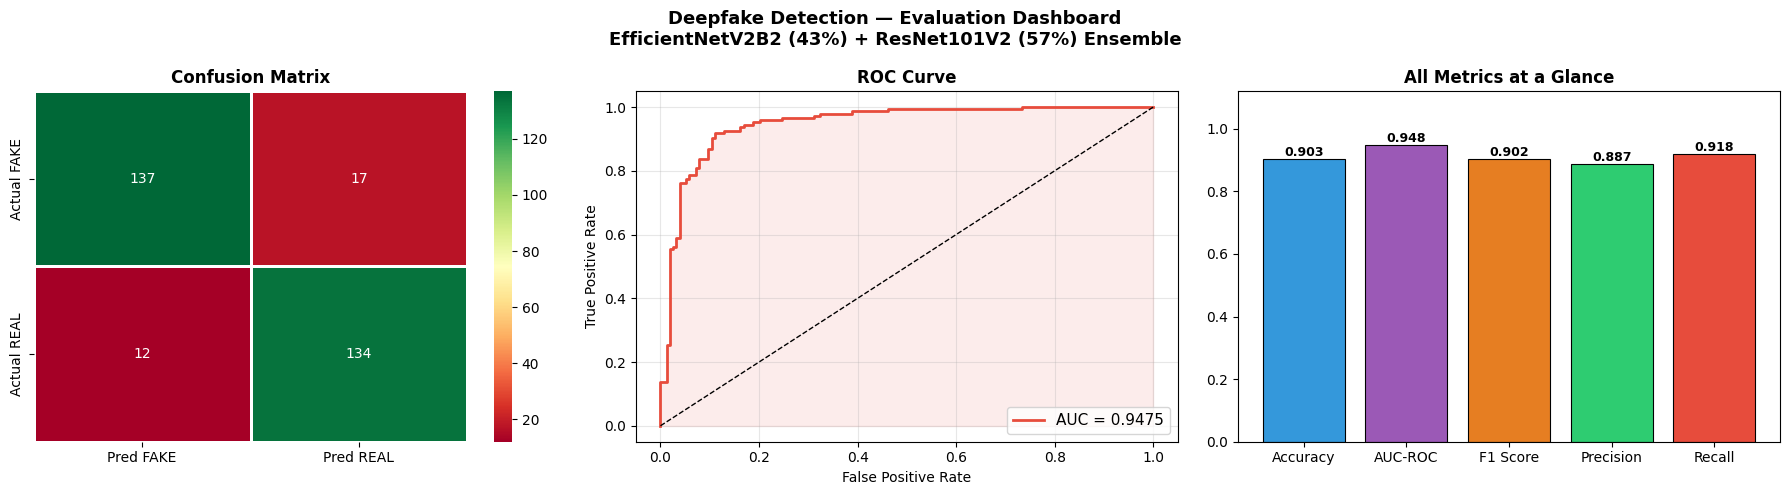


✅ Evaluation dashboard saved to Drive.


In [12]:
# ==============================================================================
# CELL 9: PROFESSIONAL EVALUATION DASHBOARD
# ------------------------------------------------------------------------------
# UPGRADED from original — added AUC-ROC, F1, Precision, Recall
# These are the metrics real ML engineers report, not just accuracy
# ==============================================================================
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, f1_score,
                              precision_score, recall_score, accuracy_score)

# Final ensemble predictions using optimal weights
ensemble_probs = (preds_effnet_val * OPTIMAL_WEIGHT_EFFNET) +                  (preds_resnet_val * OPTIMAL_WEIGHT_RESNET)
ensemble_preds = (ensemble_probs >= 0.5).astype(int).flatten()
true_flat      = true_labels.flatten()

# Calculate all metrics
acc  = accuracy_score(true_flat, ensemble_preds)
auc  = roc_auc_score(true_flat, ensemble_probs.flatten())
f1   = f1_score(true_flat, ensemble_preds)
prec = precision_score(true_flat, ensemble_preds)
rec  = recall_score(true_flat, ensemble_preds)

print("=" * 55)
print("  DEEPFAKE DETECTION — FINAL EVALUATION RESULTS")
print("=" * 55)
print(f"  Accuracy   : {acc*100:.2f}%")
print(f"  AUC-ROC    : {auc:.4f}   ← how well model separates real vs fake")
print(f"  F1 Score   : {f1:.4f}   ← balance of precision and recall")
print(f"  Precision  : {prec:.4f}   ← of flagged fakes, how many are correct")
print(f"  Recall     : {rec:.4f}   ← of all fakes, how many we caught")
print("=" * 55)
print("\n📋 Full Classification Report:")
print(classification_report(true_flat, ensemble_preds,
                             target_names=['FAKE (0)', 'REAL (1)']))

# 3-panel dashboard
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Deepfake Detection — Evaluation Dashboard\n'
             f'EfficientNetV2B2 ({OPTIMAL_WEIGHT_EFFNET:.0%}) + ResNet101V2 ({OPTIMAL_WEIGHT_RESNET:.0%}) Ensemble',
             fontsize=13, fontweight='bold')

# Panel 1: Confusion Matrix
cm = confusion_matrix(true_flat, ensemble_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', linewidths=1,
            xticklabels=['Pred FAKE', 'Pred REAL'],
            yticklabels=['Actual FAKE', 'Actual REAL'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix', fontweight='bold')

# Panel 2: ROC Curve
fpr, tpr, _ = roc_curve(true_flat, ensemble_probs.flatten())
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC = {auc:.4f}')
axes[1].plot([0,1], [0,1], 'k--', lw=1)
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(loc='lower right', fontsize=11)
axes[1].grid(alpha=0.3)

# Panel 3: Metrics Bar Chart
names  = ['Accuracy', 'AUC-ROC', 'F1 Score', 'Precision', 'Recall']
values = [acc, auc, f1, prec, rec]
colors = ['#3498db', '#9b59b6', '#e67e22', '#2ecc71', '#e74c3c']
bars   = axes[2].bar(names, values, color=colors, edgecolor='black', linewidth=0.8)
axes[2].set_ylim(0, 1.12)
axes[2].set_title('All Metrics at a Glance', fontweight='bold')
for bar, val in zip(bars, values):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(BASE_PATH + 'evaluation_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Evaluation dashboard saved to Drive.")


---
## CELL 10 — Grad-CAM: Visualize Where Model Detects Forgery
> NEW — Shows exactly which part of the image the model focused on when predicting fake.

Using last conv layer: top_conv


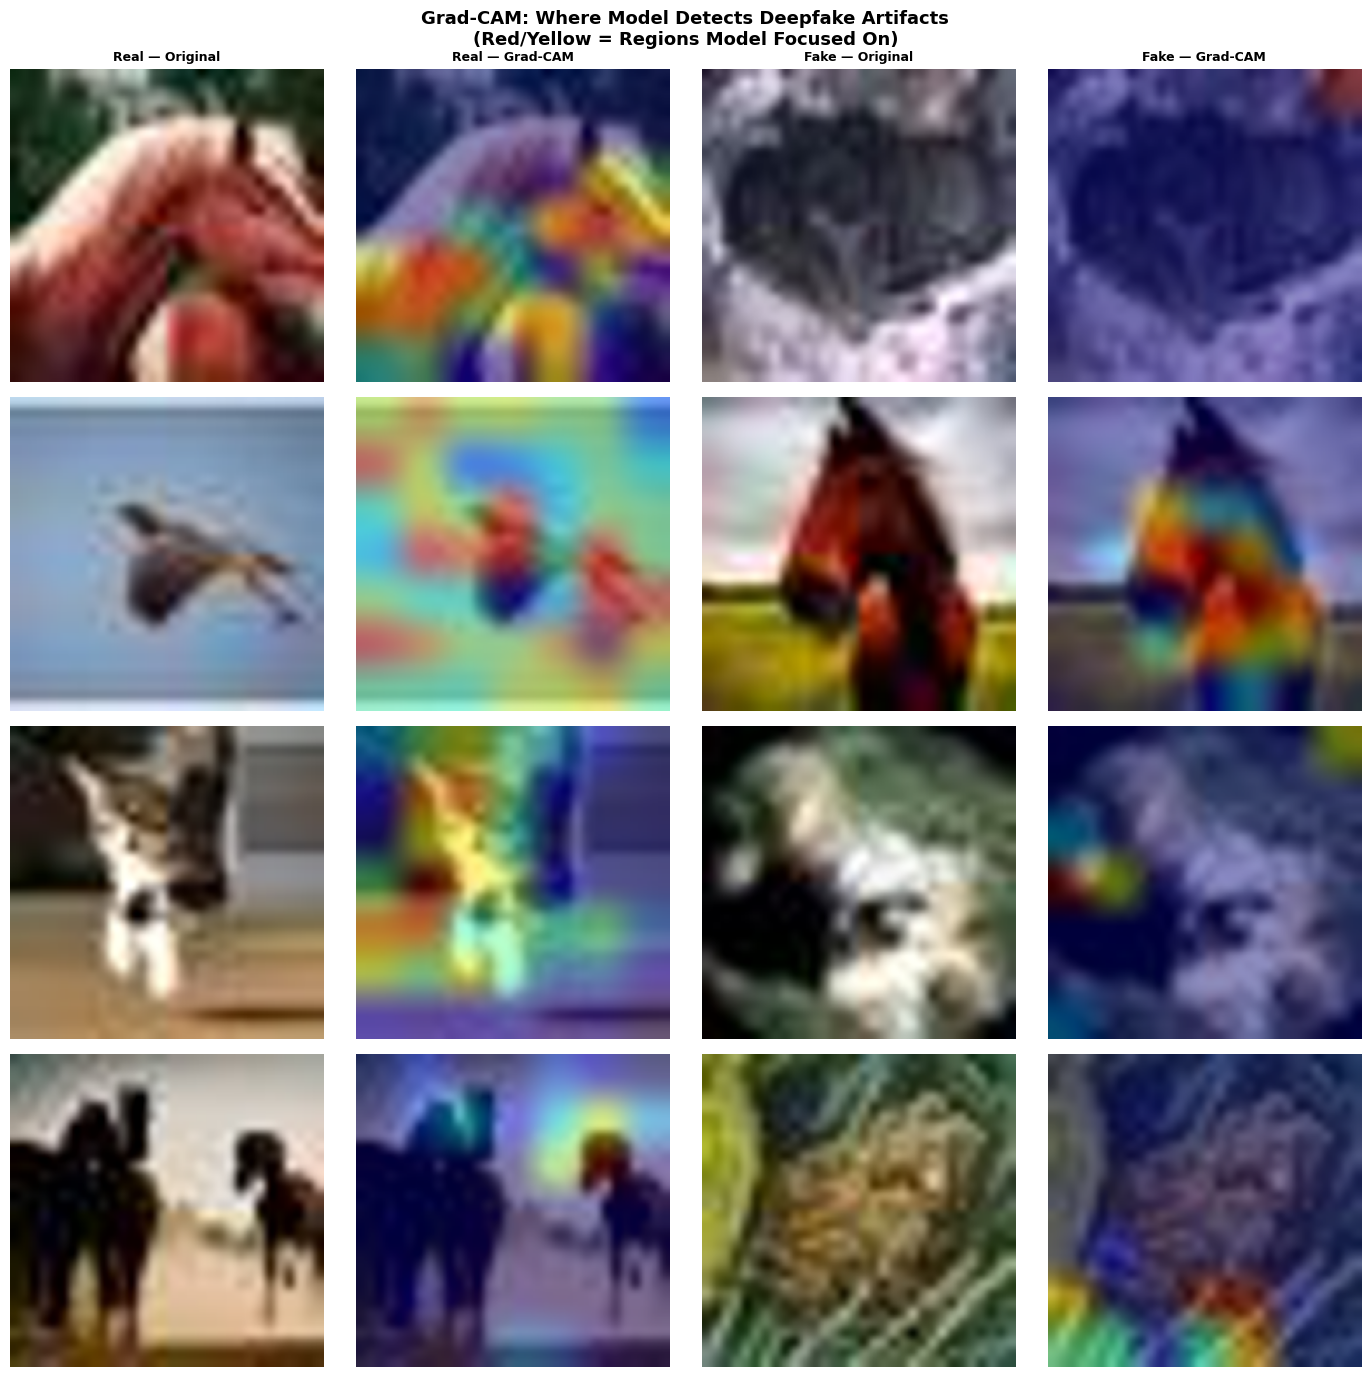

✅ Grad-CAM saved.


In [14]:
# ==============================================================================
# CELL 10: GRAD-CAM EXPLAINABILITY
# ------------------------------------------------------------------------------
# NEW ADDITION — not in original notebook
# Shows WHERE in the image the model detects deepfake artifacts
# Red/yellow = high attention regions (where model found manipulation)
# ==============================================================================
import matplotlib.cm as mpl_cm
from PIL import Image

def get_gradcam(model, img_array, last_conv_layer_name):
    """Generate Grad-CAM heatmap for given image."""
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array)
        loss = preds[:, 0]
    grads   = tape.gradient(loss, conv_out)
    pooled  = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_out[0] @ pooled[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_cam(img_path, heatmap, size=224, alpha=0.45):
    """Overlay heatmap on original image."""
    img     = np.array(Image.open(img_path).resize((size, size)))
    h       = np.uint8(255 * heatmap)
    jet = plt.colormaps['jet'](np.arange(256))[:, :3]
    colored = np.uint8(jet[h] * 255)
    colored = np.array(Image.fromarray(colored).resize((size, size)))
    return np.uint8(colored * alpha + img * (1 - alpha))

# Find last conv layer in EfficientNet
for layer in reversed(effnet_model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv = layer.name
        break
print(f"Using last conv layer: {last_conv}")

# Pick 4 real and 4 fake samples from validation set
real_paths = val_df[val_df['label'] == 1]['image_path'].tolist()[:4]
fake_paths = val_df[val_df['label'] == 0]['image_path'].tolist()[:4]
samples    = [('REAL', p) for p in real_paths] + [('FAKE', p) for p in fake_paths]

# Fixed plotting — all 8 samples in 4 rows x 4 cols
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
fig.suptitle('Grad-CAM: Where Model Detects Deepfake Artifacts\n'
             '(Red/Yellow = Regions Model Focused On)',
             fontsize=13, fontweight='bold')

for ax, title in zip(axes[0],
    ['Real — Original', 'Real — Grad-CAM', 'Fake — Original', 'Fake — Grad-CAM']):
    ax.set_title(title, fontweight='bold', fontsize=9)

# First 4 rows: 2 real + 2 fake side by side
real_paths = val_df[val_df['label'] == 1]['image_path'].tolist()[:4]
fake_paths = val_df[val_df['label'] == 0]['image_path'].tolist()[:4]

for row in range(4):
    for col_offset, (true_label, img_path) in enumerate([
        ('REAL', real_paths[row]),
        ('FAKE', fake_paths[row])
    ]):
        img     = Image.open(img_path).resize((224, 224))
        arr     = np.array(img, dtype='float32')[np.newaxis]
        preproc = tf.keras.applications.efficientnet_v2.preprocess_input(arr.copy())

        prob    = effnet_model.predict(preproc, verbose=0)[0][0]
        pred    = 'REAL' if prob > 0.5 else 'FAKE'
        conf    = prob if prob > 0.5 else 1 - prob
        color   = '#2ecc71' if pred == 'REAL' else '#e74c3c'

        heatmap = get_gradcam(effnet_model, preproc, last_conv)
        cam_img = overlay_cam(img_path, heatmap)

        col = col_offset * 2   # 0 for real, 2 for fake

        axes[row][col].imshow(img)
        axes[row][col].set_xlabel(f'GT:{true_label} Pred:{pred} ({conf:.0%})',
                                   color=color, fontsize=8)
        axes[row][col].axis('off')

        axes[row][col+1].imshow(cam_img)
        axes[row][col+1].set_xlabel('Detected region', fontsize=8, color='#e67e22')
        axes[row][col+1].axis('off')

plt.tight_layout()
plt.savefig(BASE_PATH + 'gradcam_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grad-CAM saved.")

---
## CELL 11 — Single Image Inference with Risk Scoring
> NEW — Takes any image, runs both models, returns prediction + confidence + risk level.

In [17]:
# ==============================================================================
# CELL 11: SINGLE IMAGE INFERENCE + RISK SCORING
# ------------------------------------------------------------------------------
# NEW ADDITION — not in original notebook
# This function will power the Streamlit demo
# Takes any image → runs ensemble → returns label + confidence + risk level
# ==============================================================================
from PIL import Image

def predict_image(image_path_or_pil, effnet_model, resnet_model,
                  w_eff=OPTIMAL_WEIGHT_EFFNET, w_res=OPTIMAL_WEIGHT_RESNET):
    """
    Deepfake detection inference.
    Input : image file path (str) or PIL Image
    Output: prediction dict with label, confidence, risk level
    """
    # Load image
    if isinstance(image_path_or_pil, str):
        img = Image.open(image_path_or_pil).convert('RGB').resize((224, 224))
    else:
        img = image_path_or_pil.convert('RGB').resize((224, 224))

    arr = np.array(img, dtype='float32')[np.newaxis]

    # Preprocess for each model
    eff_in = tf.keras.applications.efficientnet_v2.preprocess_input(arr.copy())
    res_in = tf.keras.applications.resnet_v2.preprocess_input(arr.copy())

    # Predict
    p_eff = float(effnet_model.predict(eff_in, verbose=0)[0][0])
    p_res = float(resnet_model.predict(res_in, verbose=0)[0][0])

    # Ensemble
    prob  = p_eff * w_eff + p_res * w_res
    label = 'REAL' if prob >= 0.5 else 'FAKE'
    conf  = prob if prob >= 0.5 else 1 - prob

    # Risk level based on confidence
    if   label == 'REAL' and conf >= 0.90: risk = '🟢 LOW RISK — Authentic Face'
    elif label == 'REAL' and conf >= 0.75: risk = '🟡 MEDIUM RISK — Review Recommended'
    elif label == 'REAL' and conf <  0.75: risk = '🟠 LOW CONFIDENCE REAL — Manual Check'
    elif label == 'FAKE' and conf <  0.80: risk = '🟠 HIGH RISK — Possible Deepfake'
    else:                                   risk = '🔴 CRITICAL — Deepfake Detected'
    return {
        'label'      : label,
        'confidence' : round(conf * 100, 2),
        'risk'       : risk,
        'prob_real'  : round(prob * 100, 2),
        'prob_fake'  : round((1 - prob) * 100, 2),
        'p_effnet'   : round(p_eff * 100, 2),
        'p_resnet'   : round(p_res * 100, 2),
    }

# ── Test on real and fake samples ─────────────────────────────────────────────
test_real = val_df[val_df['label'] == 1]['image_path'].iloc[0]
test_fake = val_df[val_df['label'] == 0]['image_path'].iloc[0]

for ground_truth, path in [('REAL', test_real), ('FAKE', test_fake)]:
    r = predict_image(path, effnet_model, resnet_model)
    print("─" * 50)
    print(f"  Ground Truth : {ground_truth}")
    print(f"  Prediction   : {r['label']}  ({r['confidence']}% confidence)")
    print(f"  Risk Level   : {r['risk']}")
    print(f"  Prob Real    : {r['prob_real']}%  |  Prob Fake : {r['prob_fake']}%")
    print(f"  EfficientNet : {r['p_effnet']}%  |  ResNet    : {r['p_resnet']}%")

print("─" * 50)
print("\n✅ Inference function working correctly.")
print("📦 Ready for Streamlit deployment.")


──────────────────────────────────────────────────
  Ground Truth : REAL
  Prediction   : REAL  (51.64% confidence)
  Risk Level   : 🟠 LOW CONFIDENCE REAL — Manual Check
  Prob Real    : 51.64%  |  Prob Fake : 48.36%
  EfficientNet : 46.7%  |  ResNet    : 55.37%
──────────────────────────────────────────────────
  Ground Truth : FAKE
  Prediction   : FAKE  (99.66% confidence)
  Risk Level   : 🔴 CRITICAL — Deepfake Detected
  Prob Real    : 0.34%  |  Prob Fake : 99.66%
  EfficientNet : 0.04%  |  ResNet    : 0.57%
──────────────────────────────────────────────────

✅ Inference function working correctly.
📦 Ready for Streamlit deployment.


---
## CELL 12 — Generate Test Submission JSON
> Original submission cell — kept as is.

In [16]:
# ==============================================================================
# CELL 12: FINAL SUBMISSION FILE GENERATION
# ------------------------------------------------------------------------------
# Original submission cell — unchanged from hackathon version
# Generates prediction JSON for test images
# ==============================================================================
print("Generating final ensemble predictions with optimized weights...")
print(f"Using weights: EfficientNet={OPTIMAL_WEIGHT_EFFNET:.2f}, ResNet={OPTIMAL_WEIGHT_RESNET:.2f}")

try:
    # Build test pipeline
    test_image_files  = os.listdir(TEST_IMG_PATH)
    df_test = pd.DataFrame({
        'image_id'   : test_image_files,
        'image_path' : TEST_IMG_PATH + pd.Series(test_image_files),
        TARGET_COLUMN: 0
    })
    test_ds_effnet = create_pipeline(df_test, effnet_preprocessor, is_training=False)
    test_ds_resnet = create_pipeline(df_test, resnet_preprocessor, is_training=False)

    # Generate predictions
    print("Generating predictions from EfficientNet...")
    preds_effnet = effnet_model.predict(test_ds_effnet)
    print("Generating predictions from ResNet...")
    preds_resnet = resnet_model.predict(test_ds_resnet)

    # Weighted ensemble
    final_preds      = (preds_effnet * OPTIMAL_WEIGHT_EFFNET) + (preds_resnet * OPTIMAL_WEIGHT_RESNET)
    predicted_labels = (final_preds > 0.5).astype(int).flatten()

    # Build submission
    df_test['prediction'] = np.where(predicted_labels == 1, 'real', 'fake')
    df_test['index']      = df_test['image_id'].str.replace('.png', '', regex=False).astype(int)

    submission_list = df_test[['index', 'prediction']].to_dict(orient='records')
    submission_list.sort(key=lambda x: x['index'])

    with open('submission_optimized.json', 'w') as f:
        json.dump(submission_list, f, indent=4)

    print("\n" + "="*50)
    print("🎉 SUBMISSION FILE CREATED SUCCESSFULLY!")
    print("✅ submission_optimized.json ready")
    print("="*50)

except Exception as e:
    print(f"❌ Error: {e}")
    raise


Generating final ensemble predictions with optimized weights...
Using weights: EfficientNet=0.43, ResNet=0.57
Generating predictions from EfficientNet...
16/16 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step
Generating predictions from ResNet...
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 441ms/step

🎉 SUBMISSION FILE CREATED SUCCESSFULLY!
✅ submission_optimized.json ready
